In [ ]:
# | default_exp utils

# Yin-Yang Model Training
> Training an MLP on the Yin-Yang classification task

#### Imports

In [ ]:
from learningdynamics.models import MLP, init_weights
from learningdynamics.datasets import YinYangBinaryDataset
from learningdynamics.visualization import plot_decision_boundary_movie
import matplotlib.pyplot as plt
import matplotlib
from torch.nn import CrossEntropyLoss
from safetensors.torch import save_model
from torch.optim import AdamW, SGD
import seaborn as sns
import numpy as np
import torch

In [ ]:
# | export
import os
from torch.nn import Module
from torch.utils.data import DataLoader, Dataset
import json
from torcheval.metrics import MulticlassAccuracy

#### Notebook config.

In [ ]:
#| hide
torch.set_printoptions(profile='default')

In [ ]:
# Dataset settings
NUM_SAMPLES = 2_000

# Visualization settings
FIGSIZE = (5, 5)
sns.set_theme(style="white", palette=None,rc={'figure.figsize':FIGSIZE})

# MLP settings
OUT_FEATURES = 2
HIDDEN_NEURONS = [8,6,4,3]  # only valid for HiddenLayerModel
NONLINEARITY = "relu"

# Training settings
BATCH_SIZE = 1_000
NUM_EPOCHS = 5_000
LEARNING_RATE = 5e-3
WEIGHT_DECAY = 1e-2
PRINT_FREQ = 500

#### Yin-Yang dataset

In [ ]:
dataset = YinYangBinaryDataset(
    num_samples=NUM_SAMPLES, negative_label=False
)

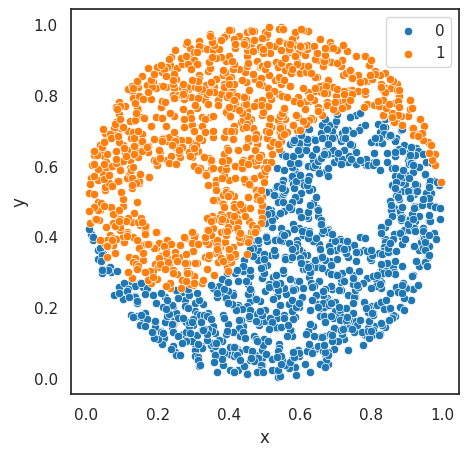

In [ ]:
# Extract features and labels
features = dataset.features
labels = dataset.labels.squeeze()

sns.scatterplot(x=features[labels == 0][:, 0], y=features[labels == 0][:, 1], label='0')
sns.scatterplot(x=features[labels == 1][:, 0], y=features[labels == 1][:, 1], label='1')

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.show()


#### Define model

In [ ]:
model = MLP(
    config=HIDDEN_NEURONS,
    in_features=dataset.features.shape[-1], 
    out_features=OUT_FEATURES,
    nonlinearity=NONLINEARITY,
)
model.apply(init_weights)

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=4, bias=True)
    (5): ReLU()
    (6): Linear(in_features=4, out_features=3, bias=True)
    (7): ReLU()
    (8): Linear(in_features=3, out_features=2, bias=True)
  )
)

#### Model training

In [ ]:
dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=BATCH_SIZE)
criterion = CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [ ]:
device = "cuda:0"
model.to(device=device)
model.train()

loss_vector = []
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0  # Track loss within the epoch

    for batch_idx, (input, label) in enumerate(dataloader):
        input, label = input.to(device), label.to(device)
        label = label.squeeze()

        optimizer.zero_grad()
        output = model(input)

        loss = criterion(output, label.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()  # Accumulate loss

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    if (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

Epoch 500/5000, Loss: 0.0762
Epoch 1000/5000, Loss: 0.0562
Epoch 1500/5000, Loss: 0.0548
Epoch 2000/5000, Loss: 0.0417
Epoch 2500/5000, Loss: 0.0286
Epoch 3000/5000, Loss: 0.0265
Epoch 3500/5000, Loss: 0.0235
Epoch 4000/5000, Loss: 0.0264
Epoch 4500/5000, Loss: 0.0224
Epoch 5000/5000, Loss: 0.0212


#### Decision boundary visualization

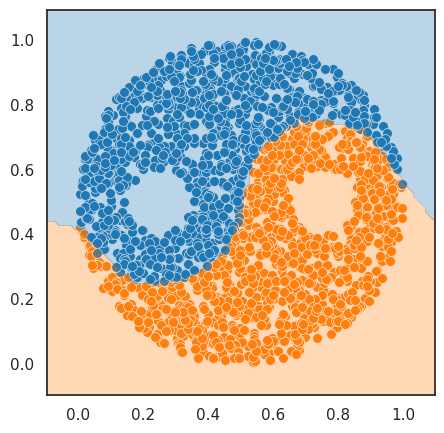

In [ ]:
# Example of integrating multiple subplots into a larger figure
fig, axs = plt.subplots(1,1, figsize=(5,5), sharex=True, sharey=True)

if type(axs) is not np.ndarray:
    axs = np.array(axs)

# Assume you have a model, state_dicts, X, and y already defined
for i, ax in enumerate(axs.flatten()):
    ani = plot_decision_boundary_movie(
            model,
            [model.state_dict()],
            dataset.features,
            dataset.labels.squeeze(),
            labels=[0, 1],
            ax=ax,
    )
    ax.get_legend().remove()
plt.show()


#### Model accuracy

In [ ]:
# | export
def compute_model_accuracy(
    model: Module,  # Model
    dataset: Dataset,  # Dataset
):
    dataloader = DataLoader(dataset, batch_size=256)
    metric = MulticlassAccuracy()
    for batch in dataloader:
        image, target = batch
        output = model(image)
        metric.update(output, target.squeeze())

    return metric.compute()

#### Save the model using `safetensors`

In [ ]:
metadata_dict = {
    "config": str(HIDDEN_NEURONS),
    "dataset": str(dataset),
    "nonlinearity": NONLINEARITY,
}
save_model(model, "../saved_weights/yinyang_model.safetensors", metadata=metadata_dict)

#### Model file parser

In [ ]:
# | export
def safetensors_metadata_parser(
    file_path: str,  # thing
):
    "Parse the metadata from safetensors file"
    header_size = 8
    meta_data = {}
    if os.stat(file_path).st_size > header_size:
        with open(file_path, "rb") as f:
            b8 = f.read(header_size)
            if len(b8) == header_size:
                header_len = int.from_bytes(b8, "little", signed=False)
                headers = f.read(header_len)
                if len(headers) == header_len:
                    meta_data = sorted(
                        json.loads(headers.decode("utf-8"))
                        .get("__metadata__", meta_data)
                        .items()
                    )
    meta_data_dict = {}
    for k, v in meta_data:
        meta_data_dict[k] = v
    return meta_data_dict

#### Model forward hooks

In [ ]:
# | export
def getActivation(
    name: str,  # name of layer
    activation_dict: dict,  # dict to store activations,
    detach: bool = True,  # do not keep computational graph
):
    def hook(model, input, output):
        if detach:
            activation_dict[name] = output.detach()
        else:
            activation_dict[name] = output

    return hook